# Metacatalog association & quality-control summary

Pipeline census for the MHz-subband metacatalog (`CATALOG_DIR`): detections → LST merge → band merge → default QC → spectral fits → external associations.

| Metric | Definition |
| --- | --- |
| Per-image detections | All `sources_{lst}_{band}.parquet` rows (22 LST × 15 subbands) |
| LST-merged | One representative per sky position **within each subband** |
| Metacatalog | Global fusion after sequential subband merge |
| Default QC (`core_clean`) | `(quality_flag & EXCLUDE_MASK) == 0` with `EXCLUDE_MASK = 33267` |
| Spectral fit | `spec_model_n_flux >= 2` (Taylor fit about 55 MHz) |
| Good spectral fit | fitted and `spec_model_chi2_red < CHI2_RED_MAX` |
| Radio match counts | from `metacatalog_radio.parquet` (`n_assoc_{VLSSR,NVSS,VLASS}`; write via `radio_crossmatch.ipynb`) |
| Unique radio / NED-LVS | exactly one association (`n_assoc_* == 1` / `n_nedlvs == 1`) |

**Reference counts** (live Parquet from quality / radio / spectral / NED-LVS rematch):

| Metric | Count |
| --- | ---: |
| Detections (all LST × subbands) | 6,195,000 |
| Metacatalog after band merge | 138,732 |
| Pass default QC | 128,352 |
| Spectral fit | 119,509 |
| Spectral fit, χ²_red < 5 | 111,686 |
| Unique VLSSR / NVSS / VLASS | 52,967 / 20,328 / 9,943 |
| Unique NED-LVS (`z ≤ 0.0223`) | 854 |

Upstream products:

| Product | Notebook |
| --- | --- |
| `metacatalog_quality.parquet` | `metacatalog_reliability.ipynb` |
| `metacatalog_radio.parquet` | `radio_crossmatch.ipynb` (`WRITE_CROSSMATCH=True`) |
| `metacatalog_spectral.parquet` | `metacatalog_spectral_modeling.ipynb` |
| NED-LVS match (this notebook) | radio `match_RA`/`match_DEC` + Diam floor; writes `metacatalog_nedlvs_flags.parquet` |

The Venn section compares **QC-cleared**, **spectral-fit**, and **unique match to VLSSR ∪ NVSS ∪ VLASS**.

**Run cells in order.** Requires `metacatalog_radio.parquet`. NED-LVS cache is reused only when newer than the radio product and row counts match.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from matplotlib.patches import Circle

from lwa_catalog import CatalogLayout, resolve_metacatalog_path
from lwa_catalog.analyze import (
    NedlvsMatchConfig,
    filter_by_quality_mask,
    match_catalog_to_nedlvs,
    quality_flag_mask_from_names,
)
from lwa_catalog.constants import (
    NEDLVS_DEFAULT_DIAM_SCALE,
    NEDLVS_DEFAULT_PATH,
    SUBBAND_METACATALOG_REQUIRED_COLUMNS,
)
from lwa_catalog.io import discover_lst_merged_bands, read_table, validate_metacatalog

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")
CHI2_RED_MAX = 5.0

# Same default exclusion set as metacatalog_reliability / radio_crossmatch / spectral modeling.
EXCLUDE_FLAGS = (
    "HAS_NAN",
    "INVALID_ASTROMETRY",
    "UNPHYSICAL_FLUX",
    "RESID_ABS_FAIL",
    "RESID_PCTL_RMS",
    "RESID_PCTL_MEAN",
    "JITTER_FAIL",
    "LARGE_SINGLE",
)
EXCLUDE_MASK = quality_flag_mask_from_names(EXCLUDE_FLAGS)  # 33267

# Radio match counts come from metacatalog_radio.parquet (radio_crossmatch.ipynb attach).
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
NEDLVS_MAX_REDSHIFT = 0.0223  # local-volume cut used in metacatalog_nedlvs_crossmatch.ipynb
NEDLVS_POSITION_SIGMA_SCALE = 3.0
NEDLVS_DIAM_SCALE = NEDLVS_DEFAULT_DIAM_SCALE  # 0.5; None disables Diam floor

# Cache NED-LVS n_nedlvs (invalidated when radio parquet is newer).
REUSE_CACHED_NEDLVS = True
WRITE_NEDLVS_CACHE = True
WRITE_ASSOC_FLAGS = True
NEDLVS_CACHE_NAME = "metacatalog_nedlvs_flags.parquet"
ASSOC_FLAGS_NAME = "metacatalog_association_flags.parquet"

layout = CatalogLayout(CATALOG_DIR)
RADIO_PATH = layout.metacatalog_radio()
SPECTRAL_PATH = layout.metacatalog_spectral()
QUALITY_PATH = layout.metacatalog_quality()
NEDLVS_CACHE = layout.root / NEDLVS_CACHE_NAME
ASSOC_FLAGS_PATH = layout.root / ASSOC_FLAGS_NAME

print("CATALOG_DIR =", layout.root.resolve())
print("quality path =", QUALITY_PATH.resolve(), "(exists)" if QUALITY_PATH.is_file() else "(missing)")
print("RADIO_PATH =", RADIO_PATH.resolve(), "(exists)" if RADIO_PATH.is_file() else "(missing)")
print("SPECTRAL_PATH =", SPECTRAL_PATH.resolve(), "(exists)" if SPECTRAL_PATH.is_file() else "(missing)")
print("default resolve_metacatalog_path =", resolve_metacatalog_path(layout))
print("EXCLUDE_MASK =", EXCLUDE_MASK, "flags =", EXCLUDE_FLAGS)
print("CHI2_RED_MAX =", CHI2_RED_MAX)
print("NEDLVS_DIAM_SCALE =", NEDLVS_DIAM_SCALE)
print("NEDLVS_CACHE =", NEDLVS_CACHE)
print("ASSOC_FLAGS_PATH =", ASSOC_FLAGS_PATH)
print("REUSE_CACHED_NEDLVS =", REUSE_CACHED_NEDLVS)


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
quality path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_quality.parquet (exists)
RADIO_PATH = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_radio.parquet (exists)
SPECTRAL_PATH = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_spectral.parquet (exists)
default resolve_metacatalog_path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_quality.parquet
EXCLUDE_MASK = 33267 flags = ('HAS_NAN', 'INVALID_ASTROMETRY', 'UNPHYSICAL_FLUX', 'RESID_ABS_FAIL', 'RESID_PCTL_RMS', 'RESID_PCTL_MEAN', 'JITTER_FAIL', 'LARGE_SINGLE')
CHI2_RED_MAX = 5.0
NEDLVS_DIAM_SCALE = 0.5
NEDLVS_CACHE = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_nedlvs_flags.parquet
ASSOC_FLAGS_PATH = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_association_flags.parquet
REUSE_CACHED_NEDLVS = True


## Pipeline source counts

Row counts from Parquet metadata / thin column reads (no full table loads).

In [2]:
def _parquet_nrows(path: Path) -> int:
    return int(pq.ParquetFile(path).metadata.num_rows)


source_paths = sorted(layout.root.glob("sources_*.parquet"))
n_detections = sum(_parquet_nrows(p) for p in source_paths)

bands = discover_lst_merged_bands(layout)
lst_counts = {band: _parquet_nrows(layout.lst_merged(band)) for band in bands}
n_lst_total = int(sum(lst_counts.values()))

n_metacatalog = _parquet_nrows(layout.metacatalog())

quality = pq.read_table(
    QUALITY_PATH,
    columns=["meta_id", "quality_flag"],
).to_pandas()
qc_mask = (quality["quality_flag"].astype("uint32") & np.uint32(EXCLUDE_MASK)) == 0
qc_ids = set(quality.loc[qc_mask, "meta_id"].tolist())
n_qc = len(qc_ids)
n_all_clear = int((quality["quality_flag"] == 0).sum())

if not SPECTRAL_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {SPECTRAL_PATH}; run metacatalog_spectral_modeling.ipynb first"
    )
spectral = pq.read_table(
    SPECTRAL_PATH,
    columns=["meta_id", "spec_model_n_flux", "spec_model_chi2_red"],
).to_pandas()
n_flux = pd.to_numeric(spectral["spec_model_n_flux"], errors="coerce")
chi2 = pd.to_numeric(spectral["spec_model_chi2_red"], errors="coerce")
fitted_mask = n_flux >= 2
good_fit_mask = fitted_mask & chi2.notna() & (chi2 < CHI2_RED_MAX)
fit_ids = set(spectral.loc[fitted_mask, "meta_id"].tolist())
good_fit_ids = set(spectral.loc[good_fit_mask, "meta_id"].tolist())
n_fitted = len(fit_ids)
n_chi2_lt = len(good_fit_ids)

lst_table = pd.DataFrame(
    {"subband": list(lst_counts.keys()), "n_lst_merged": list(lst_counts.values())}
)
display(lst_table)

pipeline_summary = pd.DataFrame(
    [
        {"metric": "Per-image detections (all LST × subbands)", "count": n_detections},
        {"metric": "LST-merged rows (sum over subbands)", "count": n_lst_total},
        {"metric": "Metacatalog after band merge", "count": n_metacatalog},
        {"metric": f"Pass default QC (mask={EXCLUDE_MASK})", "count": n_qc},
        {"metric": "quality_flag == 0 (all-clear)", "count": n_all_clear},
        {"metric": "Spectral fit (n_flux >= 2)", "count": n_fitted},
        {"metric": f"Spectral fit with chi2_red < {CHI2_RED_MAX:g}", "count": n_chi2_lt},
    ]
)
display(pipeline_summary)
print(f"{len(source_paths)} per-image catalogs; {len(bands)} LST-merged subbands")
print(f"quality mtime: {QUALITY_PATH.stat().st_mtime}")
print(f"radio mtime:   {RADIO_PATH.stat().st_mtime}")
print(f"spectral mtime:{SPECTRAL_PATH.stat().st_mtime}")


,subband,n_lst_merged
0,18MHz,9759
1,23MHz,14463
2,27MHz,20497
3,32MHz,27130
4,36MHz,34596
5,41MHz,49228
6,46MHz,57551
7,50MHz,66173
8,55MHz,74589
9,59MHz,81115


,metric,count
0,Per-image detections (all LST × subbands),6195000
1,LST-merged rows (sum over subbands),937785
2,Metacatalog after band merge,138732
3,Pass default QC (mask=33267),128352
4,quality_flag == 0 (all-clear),57403
5,Spectral fit (n_flux >= 2),119509
6,Spectral fit with chi2_red < 5,111686


330 per-image catalogs; 15 LST-merged subbands
quality mtime: 1788455728.0636475
radio mtime:   1788480474.829483
spectral mtime:1788480939.2228343


## External associations (match counts)

Radio surveys: load `n_assoc_{VLSSR,NVSS,VLASS}` from `metacatalog_radio.parquet`
(written by `radio_crossmatch.ipynb`). Unique = `n_assoc == 1`; any = `n_assoc >= 1`; multi = `n_assoc > 1`.

NED-LVS: rematch the **radio** metacatalog (QC-masked) so associations use cascaded
`match_RA`/`match_DEC` and survey σ / Diam floor (`NEDLVS_DIAM_SCALE`), matching
`metacatalog_nedlvs_crossmatch.ipynb`. Cache is reused only when it is newer than
the radio parquet and has the same row count.


In [3]:
RADIO_ASSOC_COLS = ["meta_id", "n_assoc_VLSSR", "n_assoc_NVSS", "n_assoc_VLASS"]
RADIO_RENAME = {
    "n_assoc_VLSSR": "n_vlssr",
    "n_assoc_NVSS": "n_nvss",
    "n_assoc_VLASS": "n_vlass",
}


def _load_radio_assoc(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {path}; run radio_crossmatch.ipynb write cell "
            "(WRITE_CROSSMATCH=True) to create metacatalog_radio.parquet"
        )
    radio = pq.read_table(path, columns=RADIO_ASSOC_COLS).to_pandas()
    missing = [c for c in RADIO_ASSOC_COLS if c not in radio.columns]
    if missing:
        raise ValueError(f"{path} missing columns {missing}")
    out = radio.rename(columns=RADIO_RENAME)
    for col in ("n_vlssr", "n_nvss", "n_vlass"):
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)
    return out


def _nedlvs_cache_is_fresh(cache: Path, radio: Path, n_expected: int) -> bool:
    if not cache.is_file() or not radio.is_file():
        return False
    if cache.stat().st_mtime < radio.stat().st_mtime:
        print(f"NED-LVS cache older than radio parquet; recomputing")
        return False
    n_cache = int(pq.ParquetFile(cache).metadata.num_rows)
    if n_cache != n_expected:
        print(f"NED-LVS cache rows {n_cache} != radio {n_expected}; recomputing")
        return False
    return True


def _load_nedlvs_cache(path: Path) -> pd.DataFrame | None:
    if not path.is_file():
        return None
    cached = pq.read_table(path).to_pandas()
    if "meta_id" not in cached.columns or "n_nedlvs" not in cached.columns:
        print("NED-LVS cache missing columns; recomputing")
        return None
    out = cached[["meta_id", "n_nedlvs"]].copy()
    out["n_nedlvs"] = pd.to_numeric(out["n_nedlvs"], errors="coerce").fillna(0).astype(int)
    return out


def _compute_nedlvs_flags(meta: pd.DataFrame) -> pd.DataFrame:
    ned_cfg = NedlvsMatchConfig(
        catalog_path=NEDLVS_PATH,
        target="metacatalog",
        position_sigma_scale=NEDLVS_POSITION_SIGMA_SCALE,
        max_redshift=NEDLVS_MAX_REDSHIFT,
        diam_scale=NEDLVS_DIAM_SCALE,
    )
    print(
        "Matching NED-LVS "
        f"(sigma_scale={NEDLVS_POSITION_SIGMA_SCALE}, diam_scale={NEDLVS_DIAM_SCALE}, "
        f"match_RA={'match_RA' in meta.columns})…"
    )
    ned = match_catalog_to_nedlvs(meta, config=ned_cfg).meta_flags
    out = meta[["meta_id"]].copy()
    out = out.merge(ned[["meta_id", "n_nedlvs"]], on="meta_id", how="left")
    out["n_nedlvs"] = pd.to_numeric(out["n_nedlvs"], errors="coerce").fillna(0).astype(int)
    return out


def _load_radio_metacatalog_for_nedlvs(path: Path) -> pd.DataFrame:
    """Load radio parquet, validate, and apply the default QC mask."""
    meta = read_table(path, as_pandas=True)
    validate_metacatalog(meta, required=SUBBAND_METACATALOG_REQUIRED_COLUMNS)
    if EXCLUDE_MASK is not None:
        meta = filter_by_quality_mask(meta, EXCLUDE_MASK).reset_index(drop=True)
    return meta


assoc = _load_radio_assoc(RADIO_PATH)
print(f"Loaded radio associations: {RADIO_PATH} ({len(assoc)} rows)")

ned = None
if REUSE_CACHED_NEDLVS and _nedlvs_cache_is_fresh(NEDLVS_CACHE, RADIO_PATH, len(assoc)):
    ned = _load_nedlvs_cache(NEDLVS_CACHE)
    if ned is not None:
        print(f"Loaded NED-LVS cache: {NEDLVS_CACHE} ({len(ned)} rows)")

if ned is None:
    meta_radio = _load_radio_metacatalog_for_nedlvs(RADIO_PATH)
    print(
        f"Radio metacatalog rows for NED-LVS matching: {len(meta_radio)} "
        f"(match_RA={('match_RA' in meta_radio.columns)}, "
        f"match_source={('match_source' in meta_radio.columns)})"
    )
    ned = _compute_nedlvs_flags(meta_radio)
    if WRITE_NEDLVS_CACHE:
        ned.to_parquet(NEDLVS_CACHE, index=False)
        print(f"Wrote {NEDLVS_CACHE}")

assoc = assoc.merge(ned, on="meta_id", how="left")
assoc["n_nedlvs"] = pd.to_numeric(assoc["n_nedlvs"], errors="coerce").fillna(0).astype(int)

if WRITE_ASSOC_FLAGS:
    flags_out = assoc[["meta_id", "n_vlssr", "n_nvss", "n_vlass", "n_nedlvs"]].copy()
    flags_out.to_parquet(ASSOC_FLAGS_PATH, index=False)
    print(f"Wrote {ASSOC_FLAGS_PATH} ({len(flags_out)} rows)")

n_unique_vlssr = int((assoc["n_vlssr"] == 1).sum())
n_unique_nvss = int((assoc["n_nvss"] == 1).sum())
n_unique_vlass = int((assoc["n_vlass"] == 1).sum())
n_unique_nedlvs = int((assoc["n_nedlvs"] == 1).sum())
n_any_radio_unique = int(
    ((assoc["n_vlssr"] == 1) | (assoc["n_nvss"] == 1) | (assoc["n_vlass"] == 1)).sum()
)
n_any_radio = int(
    ((assoc["n_vlssr"] >= 1) | (assoc["n_nvss"] >= 1) | (assoc["n_vlass"] >= 1)).sum()
)

assoc_summary = pd.DataFrame(
    [
        {
            "survey": "VLSSR",
            "unique (n==1)": n_unique_vlssr,
            "any (n>=1)": int((assoc["n_vlssr"] >= 1).sum()),
            "multi (n>1)": int((assoc["n_vlssr"] > 1).sum()),
        },
        {
            "survey": "NVSS",
            "unique (n==1)": n_unique_nvss,
            "any (n>=1)": int((assoc["n_nvss"] >= 1).sum()),
            "multi (n>1)": int((assoc["n_nvss"] > 1).sum()),
        },
        {
            "survey": "VLASS",
            "unique (n==1)": n_unique_vlass,
            "any (n>=1)": int((assoc["n_vlass"] >= 1).sum()),
            "multi (n>1)": int((assoc["n_vlass"] > 1).sum()),
        },
        {
            "survey": "NED-LVS",
            "unique (n==1)": n_unique_nedlvs,
            "any (n>=1)": int((assoc["n_nedlvs"] >= 1).sum()),
            "multi (n>1)": int((assoc["n_nedlvs"] > 1).sum()),
        },
        {
            "survey": "VLSSR∪NVSS∪VLASS (unique-or)",
            "unique (n==1)": n_any_radio_unique,
            "any (n>=1)": n_any_radio,
            "multi (n>1)": int(
                ((assoc["n_vlssr"] > 1) | (assoc["n_nvss"] > 1) | (assoc["n_vlass"] > 1)).sum()
            ),
        },
    ]
)
display(assoc_summary)


Loaded radio associations: /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_radio.parquet (128352 rows)
Loaded NED-LVS cache: /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_nedlvs_flags.parquet (128352 rows)
Wrote /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_association_flags.parquet (128352 rows)


,survey,unique (n==1),any (n>=1),multi (n>1)
0,VLSSR,52967,58566,5599
1,NVSS,20328,35322,14994
2,VLASS,9943,23183,13240
3,NED-LVS,854,1177,323
4,VLSSR∪NVSS∪VLASS (unique-or),66990,80061,15523


## Combined summary table

In [4]:
summary = pd.DataFrame(
    [
        {"metric": "Sources detected (all LST × subbands)", "count": n_detections},
        {"metric": "Sources per subband after LST merge (see table above)", "count": n_lst_total},
        {"metric": "Sources in metacatalog after band merge", "count": n_metacatalog},
        {"metric": "Sources passing default QC", "count": n_qc},
        {"metric": "Sources with spectral fit", "count": n_fitted},
        {"metric": f"Sources with spectral fit (chi2_red < {CHI2_RED_MAX:g})", "count": n_chi2_lt},
        {"metric": "Unique VLSSR associations", "count": n_unique_vlssr},
        {"metric": "Unique NVSS associations", "count": n_unique_nvss},
        {"metric": "Unique VLASS associations", "count": n_unique_vlass},
        {"metric": "Unique NED-LVS associations", "count": n_unique_nedlvs},
    ]
)
display(summary)
print(summary.to_string(index=False))

# Markdown-ready reference block for the intro cell (paste after re-run if desired).
print()
print("Reference counts (live Parquet):")
print(f"| Detections (all LST × subbands) | {n_detections:,} |")
print(f"| Metacatalog after band merge | {n_metacatalog:,} |")
print(f"| Pass default QC | {n_qc:,} |")
print(f"| Spectral fit | {n_fitted:,} |")
print(f"| Spectral fit, χ²_red < {CHI2_RED_MAX:g} | {n_chi2_lt:,} |")
print(
    f"| Unique VLSSR / NVSS / VLASS | "
    f"{n_unique_vlssr:,} / {n_unique_nvss:,} / {n_unique_vlass:,} |"
)
print(f"| Unique NED-LVS (z ≤ {NEDLVS_MAX_REDSHIFT}) | {n_unique_nedlvs:,} |")


,metric,count
0,Sources detected (all LST × subbands),6195000
1,Sources per subband after LST merge (see table...,937785
2,Sources in metacatalog after band merge,138732
3,Sources passing default QC,128352
4,Sources with spectral fit,119509
5,Sources with spectral fit (chi2_red < 5),111686
6,Unique VLSSR associations,52967
7,Unique NVSS associations,20328
8,Unique VLASS associations,9943
9,Unique NED-LVS associations,854


                                               metric   count
                Sources detected (all LST × subbands) 6195000
Sources per subband after LST merge (see table above)  937785
              Sources in metacatalog after band merge  138732
                           Sources passing default QC  128352
                            Sources with spectral fit  119509
             Sources with spectral fit (chi2_red < 5)  111686
                            Unique VLSSR associations   52967
                             Unique NVSS associations   20328
                            Unique VLASS associations    9943
                          Unique NED-LVS associations     854

Reference counts (live Parquet):
| Detections (all LST × subbands) | 6,195,000 |
| Metacatalog after band merge | 138,732 |
| Pass default QC | 128,352 |
| Spectral fit | 119,509 |
| Spectral fit, χ²_red < 5 | 111,686 |
| Unique VLSSR / NVSS / VLASS | 52,967 / 20,328 / 9,943 |
| Unique NED-LVS (z ≤ 0.0223) | 854 |


## Venn diagram: QC ∩ spectral fit ∩ radio unique

Three sets on `meta_id`:

1. **QC** — passes default quality mask
2. **Spectral** — has a Taylor spectral fit (`n_flux >= 2`)
3. **Radio** — unique association (`n_assoc == 1`) to at least one of VLSSR / NVSS / VLASS

Uses `matplotlib` only (no `matplotlib-venn` dependency). Set sizes and pairwise/triple overlaps are printed under the figure.


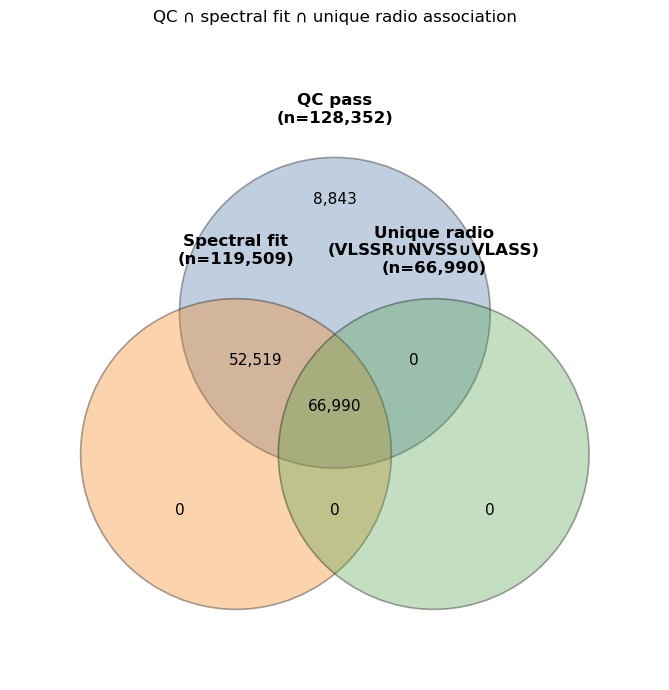

,region,count
0,QC only,8843
1,Spectral only (unexpected if spectral ⊆ QC),0
2,Radio only (outside QC),0
3,QC ∩ Spectral (not radio),52519
4,QC ∩ Radio (no spectral fit),0
5,Spectral ∩ Radio (outside QC),0
6,QC ∩ Spectral ∩ Radio,66990
7,|QC ∩ Spectral|,119509
8,|QC ∩ Radio|,66990
9,|Spectral ∩ Radio|,66990


In [5]:
def venn3_counts(a: set, b: set, c: set) -> dict[str, int]:
    """Return labeled region counts for three sets (Abc, aBc, …, ABC)."""
    only_a = a - b - c
    only_b = b - a - c
    only_c = c - a - b
    ab = (a & b) - c
    ac = (a & c) - b
    bc = (b & c) - a
    abc = a & b & c
    return {
        "100": len(only_a),
        "010": len(only_b),
        "001": len(only_c),
        "110": len(ab),
        "101": len(ac),
        "011": len(bc),
        "111": len(abc),
        "|A|": len(a),
        "|B|": len(b),
        "|C|": len(c),
        "|A∩B|": len(a & b),
        "|A∩C|": len(a & c),
        "|B∩C|": len(b & c),
        "|A∩B∩C|": len(abc),
    }


def plot_venn3(
    counts: dict[str, int],
    *,
    labels: tuple[str, str, str] = ("A", "B", "C"),
    colors: tuple[str, str, str] = ("#4C78A8", "#F58518", "#54A24B"),
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Draw a schematic 3-circle Venn with region counts (areas not to scale)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 6.5))

    centers = ((0.0, 0.15), (-0.35, -0.35), (0.35, -0.35))
    radius = 0.55
    for (x, y), color, label in zip(centers, colors, labels, strict=True):
        ax.add_patch(
            Circle(
                (x, y),
                radius,
                facecolor=color,
                edgecolor="black",
                alpha=0.35,
                linewidth=1.2,
            )
        )
        ax.text(x, y + 0.72, label, ha="center", va="center", fontsize=12, fontweight="bold")

    # Approximate label positions for each region.
    positions = {
        "100": (0.0, 0.55),
        "010": (-0.55, -0.55),
        "001": (0.55, -0.55),
        "110": (-0.28, -0.02),
        "101": (0.28, -0.02),
        "011": (0.0, -0.55),
        "111": (0.0, -0.18),
    }
    for key, (x, y) in positions.items():
        ax.text(x, y, f"{counts[key]:,}", ha="center", va="center", fontsize=11)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


radio_ids = set(
    assoc.loc[
        (assoc["n_vlssr"] == 1) | (assoc["n_nvss"] == 1) | (assoc["n_vlass"] == 1),
        "meta_id",
    ].tolist()
)

set_qc = qc_ids
set_fit = fit_ids
set_radio = radio_ids

counts = venn3_counts(set_qc, set_fit, set_radio)
labels = (
    f"QC pass\n(n={counts['|A|']:,})",
    f"Spectral fit\n(n={counts['|B|']:,})",
    f"Unique radio\n(VLSSR∪NVSS∪VLASS)\n(n={counts['|C|']:,})",
)

fig, ax = plt.subplots(figsize=(8, 7))
plot_venn3(counts, labels=labels, ax=ax)
ax.set_title("QC ∩ spectral fit ∩ unique radio association")
plt.tight_layout()
plt.show()

overlap = pd.DataFrame(
    [
        {"region": "QC only", "count": counts["100"]},
        {"region": "Spectral only (unexpected if spectral ⊆ QC)", "count": counts["010"]},
        {"region": "Radio only (outside QC)", "count": counts["001"]},
        {"region": "QC ∩ Spectral (not radio)", "count": counts["110"]},
        {"region": "QC ∩ Radio (no spectral fit)", "count": counts["101"]},
        {"region": "Spectral ∩ Radio (outside QC)", "count": counts["011"]},
        {"region": "QC ∩ Spectral ∩ Radio", "count": counts["111"]},
        {"region": "|QC ∩ Spectral|", "count": counts["|A∩B|"]},
        {"region": "|QC ∩ Radio|", "count": counts["|A∩C|"]},
        {"region": "|Spectral ∩ Radio|", "count": counts["|B∩C|"]},
    ]
)
display(overlap)

### Optional: swap spectral set to χ²_red < 5

Re-run the next cell to redraw the Venn using good spectral fits instead of all fits.

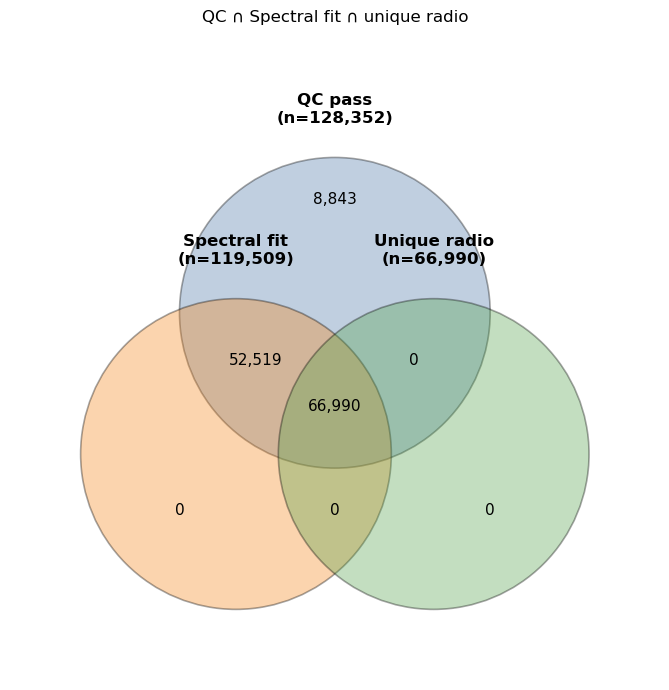

Triple intersection: 66,990  |  QC∩fit: 119,509  |  QC∩radio: 66,990  |  fit∩radio: 66,990


In [6]:
USE_GOOD_FIT_FOR_VENN = False  # True → spectral set = chi2_red < CHI2_RED_MAX

set_fit_venn = good_fit_ids if USE_GOOD_FIT_FOR_VENN else fit_ids
fit_label = (
    f"Spectral χ²_red < {CHI2_RED_MAX:g}"
    if USE_GOOD_FIT_FOR_VENN
    else "Spectral fit"
)
counts2 = venn3_counts(set_qc, set_fit_venn, set_radio)
labels2 = (
    f"QC pass\n(n={counts2['|A|']:,})",
    f"{fit_label}\n(n={counts2['|B|']:,})",
    f"Unique radio\n(n={counts2['|C|']:,})",
)
fig, ax = plt.subplots(figsize=(8, 7))
plot_venn3(counts2, labels=labels2, ax=ax)
ax.set_title(f"QC ∩ {fit_label} ∩ unique radio")
plt.tight_layout()
plt.show()
print(
    f"Triple intersection: {counts2['111']:,}  |  "
    f"QC∩fit: {counts2['|A∩B|']:,}  |  "
    f"QC∩radio: {counts2['|A∩C|']:,}  |  "
    f"fit∩radio: {counts2['|B∩C|']:,}"
)